In [ ]:
# Task 1: Dataset Acquisition
import pandas as pd

# you can download the dataset using its URL.
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"

# Read the dataset directly from the URL
df = pd.read_csv(url)

print("Dataset downloaded successfully!")

# Keep an untouched copy for comparison later
df_original = df.copy()

Dataset downloaded successfully!


In [ ]:
# Task 2: Load and Display Dataset

# Display the first 5 rows, df.head() display 5 rows by default
print(df.head())

    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1  
2       

In [ ]:
# Task 3: Dataset Summary
# shape returns (number_of_rows, number_of_columns)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 299
Number of columns: 13


In [ ]:
# Display the data type of every column
print(df.dtypes)

age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object


In [ ]:
# Count missing values in every column
print(df.isnull().sum())  #isnull returns true for missing val and false if value is present and sum() counts the true values

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [ ]:
# Gives general information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


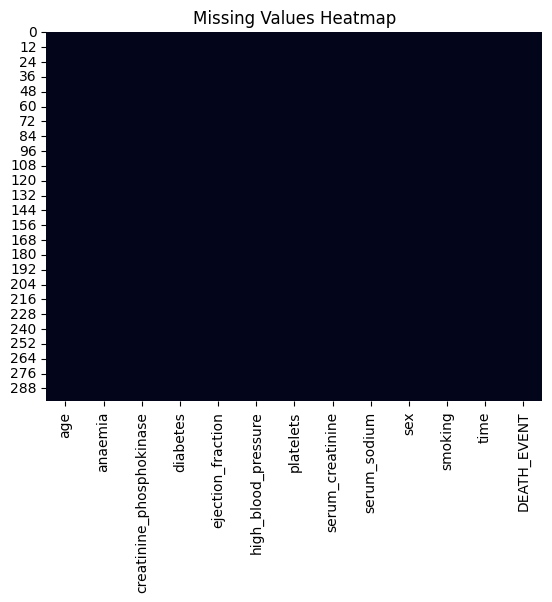

In [ ]:
# Task 4: Visualize Missing Values

import seaborn as sns
import matplotlib.pyplot as plt

# Create a heatmap showing missing values
sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.show()

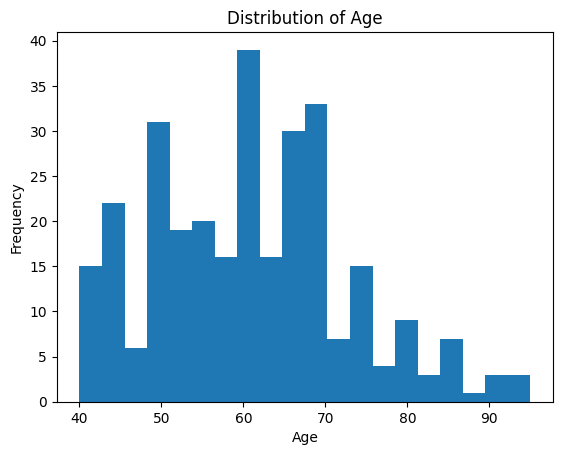

In [ ]:
# Task 5: Plot Distributions

# Create a histogram for age
plt.hist(df["age"], bins=20)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")
plt.show()

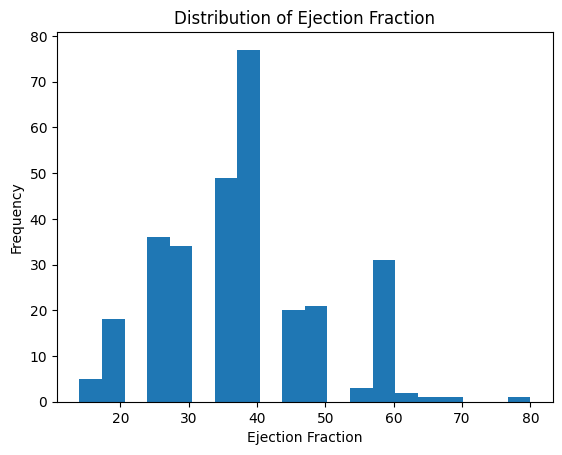

In [ ]:
# Histogram for ejection_fraction
plt.hist(df["ejection_fraction"], bins=20)

plt.xlabel("Ejection Fraction")
plt.ylabel("Frequency")
plt.title("Distribution of Ejection Fraction")

plt.show()

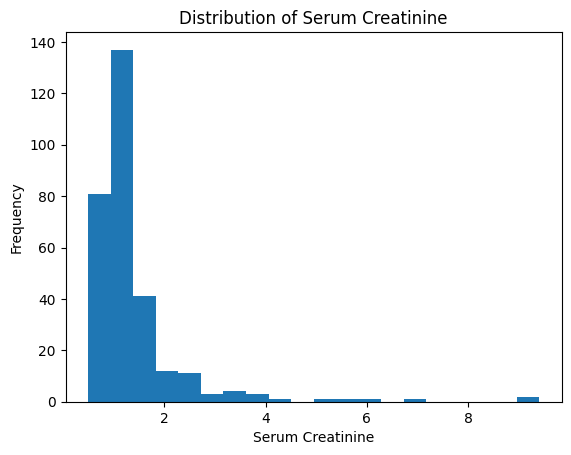

In [ ]:
# Histogram for serum_creatinine
plt.hist(df["serum_creatinine"], bins=20)

plt.xlabel("Serum Creatinine")
plt.ylabel("Frequency")
plt.title("Distribution of Serum Creatinine")

plt.show()

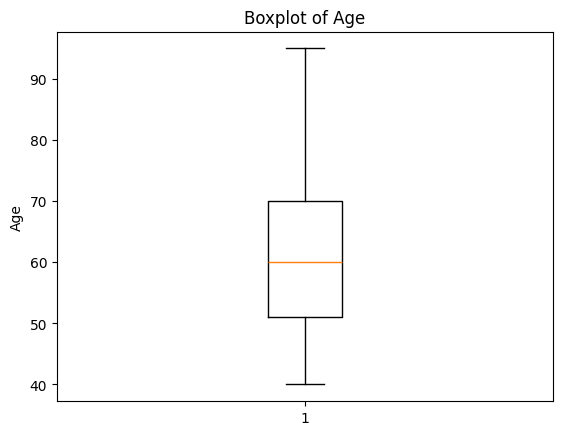

In [ ]:
# Boxplot for numerical features, A boxplot is particularly useful for finding outliers.
plt.boxplot(df["age"])

plt.ylabel("Age")
plt.title("Boxplot of Age")

plt.show()

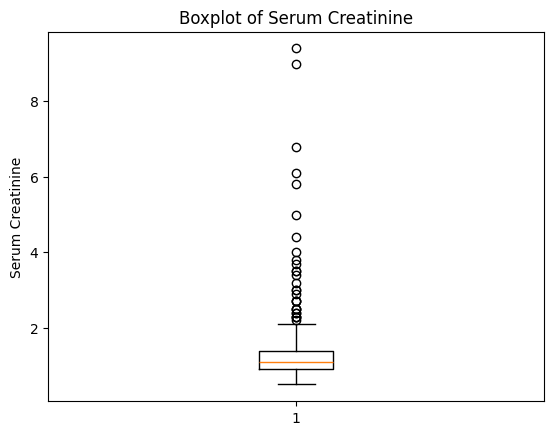

In [ ]:
# another example
plt.boxplot(df["serum_creatinine"])

plt.ylabel("Serum Creatinine")
plt.title("Boxplot of Serum Creatinine")

plt.show()

In [ ]:
# Task 6: Impute Missing Values

# List of numerical columns
numerical_columns = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]

# Replace missing values with the median of each column
for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

In [ ]:
# Categorical columns

categorical_columns = [
    "anaemia",
    "diabetes",
    "high_blood_pressure",
    "sex",
    "smoking"
]

# Replace missing values with the most common value (mode)
for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [ ]:
# Task 7: Remove Outliers

# Function to remove outliers using IQR
def remove_outliers(df, column):

    # First quartile
    Q1 = df[column].quantile(0.25)

    # Third quartile
    Q3 = df[column].quantile(0.75)

    # Interquartile range
    IQR = Q3 - Q1

    # Lower limit
    lower_limit = Q1 - 1.5 * IQR

    # Upper limit
    upper_limit = Q3 + 1.5 * IQR

    # Keep only values within the limits
    df = df[
        (df[column] >= lower_limit) &
        (df[column] <= upper_limit)
    ]

    return df

In [ ]:
# Columns where we want to remove outliers

outlier_columns = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium"
]

# Remove outliers from each column
for column in outlier_columns:
    df = remove_outliers(df, column)

print("Rows after removing outliers:", len(df))

Rows after removing outliers: 224


In [ ]:
# Task 8: Check for invalid age values
print("Negative ages:")
print(df[df["age"] < 0])

Negative ages:
Empty DataFrame
Columns: [age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets, serum_creatinine, serum_sodium, sex, smoking, time, DEATH_EVENT]
Index: []


In [ ]:
# Remove rows where age is negative

df = df[df["age"] >= 0]

In [ ]:
# Age should not be zero or negative
print(df[df["age"] <= 0])

# Ejection fraction should be positive
print(df[df["ejection_fraction"] <= 0])

# Serum creatinine should be positive
print(df[df["serum_creatinine"] <= 0])

# Serum sodium should be positive
print(df[df["serum_sodium"] <= 0])

Empty DataFrame
Columns: [age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets, serum_creatinine, serum_sodium, sex, smoking, time, DEATH_EVENT]
Index: []
Empty DataFrame
Columns: [age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets, serum_creatinine, serum_sodium, sex, smoking, time, DEATH_EVENT]
Index: []
Empty DataFrame
Columns: [age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets, serum_creatinine, serum_sodium, sex, smoking, time, DEATH_EVENT]
Index: []
Empty DataFrame
Columns: [age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets, serum_creatinine, serum_sodium, sex, smoking, time, DEATH_EVENT]
Index: []


In [ ]:
# we can remove invalid records if found:
df = df[df["age"] > 0]
df = df[df["ejection_fraction"] > 0]
df = df[df["serum_creatinine"] > 0]
df = df[df["serum_sodium"] > 0]

In [ ]:
# Task 9: Feature Engineering

# Create age groups
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 40, 60, float("inf")],
    labels=["<40", "40-60", ">60"]
)

# Display the result
print(df[["age", "age_group"]].head(10))

     age age_group
0   75.0       >60
2   65.0       >60
3   50.0     40-60
5   90.0       >60
6   75.0       >60
8   65.0       >60
11  62.0       >60
12  45.0     40-60
13  50.0     40-60
14  49.0     40-60


In [ ]:
# create Risk-score. we need to normalize product of ejection_fraction and serum_creatinine

# Normalize ejection_fraction
df["ejection_fraction_norm"] = (
    (df["ejection_fraction"] - df["ejection_fraction"].min()) /
    (df["ejection_fraction"].max() - df["ejection_fraction"].min())
)

# Normalize serum_creatinine
df["serum_creatinine_norm"] = (
    (df["serum_creatinine"] - df["serum_creatinine"].min()) /
    (df["serum_creatinine"].max() - df["serum_creatinine"].min())
)

In [ ]:
# Create risk score as the product of the normalized features
df["risk_score"] = (
    df["ejection_fraction_norm"] *
    df["serum_creatinine_norm"]
)

print(df[[
    "ejection_fraction",
    "serum_creatinine",
    "risk_score"
]].head())

   ejection_fraction  serum_creatinine  risk_score
0                 20               1.9    0.101961
2                 20               1.3    0.054902
3                 20               1.9    0.101961
5                 40               2.1    0.509804
6                 15               1.2    0.007843


In [ ]:
# Task 10: One-Hot Encoding

# Convert age_group into separate 0/1 columns
df = pd.get_dummies(
    df,
    columns=["age_group"],
    dtype=int
)

print(df.head())

    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
5  90.0        1                        47         0                 40   
6  75.0        1                       246         0                 15   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1   265000.0               1.9           130    1   
2                    0   162000.0               1.3           129    1   
3                    0   210000.0               1.9           137    1   
5                    1   204000.0               2.1           132    1   
6                    0   127000.0               1.2           137    1   

   smoking  time  DEATH_EVENT  ejection_fraction_norm  serum_creatinine_norm  \
0        0     4        

In [ ]:
# Task 11: Normalize Numerical Features

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler() # Create the scaler

numerical_columns = [   # Numerical columns we want to scale
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time",
    "risk_score"
]

# Apply MinMaxScaler, It converts values approximately into: 0 to 1
df[numerical_columns] = scaler.fit_transform(
    df[numerical_columns]
)

print(df[numerical_columns].head())

        age  creatinine_phosphokinase  ejection_fraction  platelets  \
0  0.636364                  0.470990           0.117647   0.468852   
2  0.454545                  0.098976           0.117647   0.131148   
3  0.181818                  0.069113           0.117647   0.288525   
5  0.909091                  0.014505           0.509804   0.268852   
6  0.636364                  0.184300           0.019608   0.016393   

   serum_creatinine  serum_sodium      time  risk_score  
0          0.866667      0.217391  0.000000    0.169935  
2          0.466667      0.173913  0.010676    0.091503  
3          0.866667      0.521739  0.010676    0.169935  
5          1.000000      0.304348  0.014235    0.849673  
6          0.400000      0.521739  0.021352    0.013072  


In [ ]:
# Keep an untouched copy of the original dataset
df_original = df.copy()

In [ ]:
# Task 12: Statistics Before Cleaning

print("BEFORE CLEANING")

print("Mean:")
print(df_original[numerical_columns].mean())

print("\nMedian:")
print(df_original[numerical_columns].median())

print("\nStandard Deviation:")
print(df_original[numerical_columns].std())

BEFORE CLEANING
Mean:
age                         0.378355
creatinine_phosphokinase    0.261896
ejection_fraction           0.474090
platelets                   0.438902
serum_creatinine            0.352381
serum_sodium                0.523680
time                        0.457836
risk_score                  0.261985
dtype: float64

Median:
age                         0.363636
creatinine_phosphokinase    0.155290
ejection_fraction           0.470588
platelets                   0.460656
serum_creatinine            0.333333
serum_sodium                0.521739
time                        0.412811
risk_score                  0.209150
dtype: float64

Standard Deviation:
age                         0.217202
creatinine_phosphokinase    0.238499
ejection_fraction           0.229624
platelets                   0.220176
serum_creatinine            0.218530
serum_sodium                0.165510
time                        0.272526
risk_score                  0.198141
dtype: float64


In [ ]:
# Statistics After Cleaning

print("AFTER CLEANING")

print("Mean:")
print(df[numerical_columns].mean())

print("\nMedian:")
print(df[numerical_columns].median())

print("\nStandard Deviation:")
print(df[numerical_columns].std())

AFTER CLEANING
Mean:
age                         0.378355
creatinine_phosphokinase    0.261896
ejection_fraction           0.474090
platelets                   0.438902
serum_creatinine            0.352381
serum_sodium                0.523680
time                        0.457836
risk_score                  0.261985
dtype: float64

Median:
age                         0.363636
creatinine_phosphokinase    0.155290
ejection_fraction           0.470588
platelets                   0.460656
serum_creatinine            0.333333
serum_sodium                0.521739
time                        0.412811
risk_score                  0.209150
dtype: float64

Standard Deviation:
age                         0.217202
creatinine_phosphokinase    0.238499
ejection_fraction           0.229624
platelets                   0.220176
serum_creatinine            0.218530
serum_sodium                0.165510
time                        0.272526
risk_score                  0.198141
dtype: float64


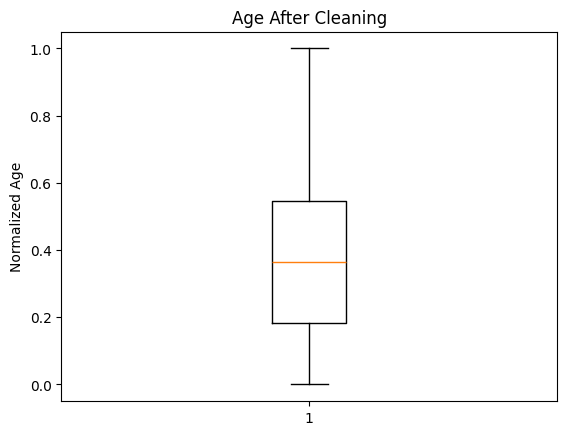

In [ ]:
# Task 13: Validate Cleaning

# Boxplot of cleaned age
plt.boxplot(df["age"])

plt.ylabel("Normalized Age")
plt.title("Age After Cleaning")

plt.show()

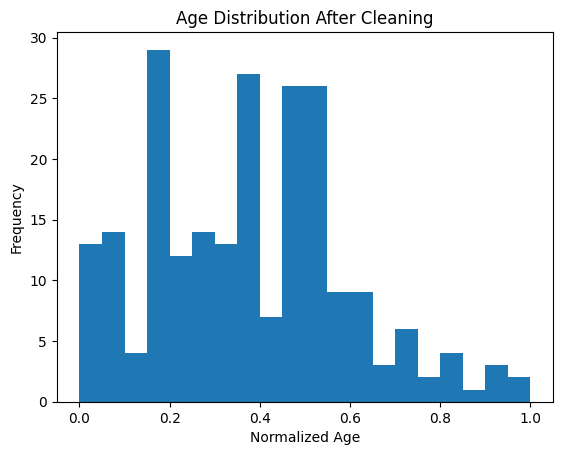

In [ ]:
# Histogram of cleaned age

plt.hist(df["age"], bins=20)

plt.xlabel("Normalized Age")
plt.ylabel("Frequency")
plt.title("Age Distribution After Cleaning")

plt.show()

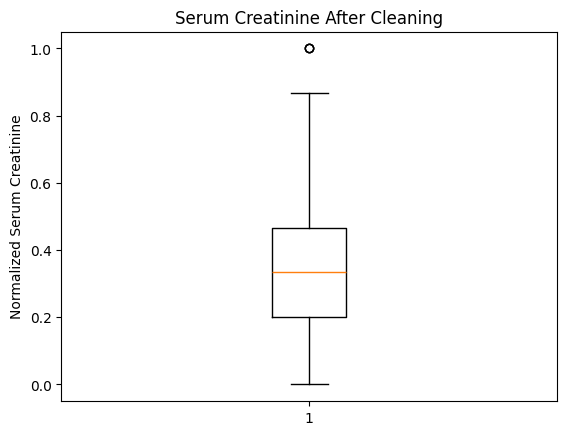

In [ ]:
# Boxplot of cleaned serum creatinine

plt.boxplot(df["serum_creatinine"])

plt.ylabel("Normalized Serum Creatinine")
plt.title("Serum Creatinine After Cleaning")

plt.show()

In [ ]:
# Task 14: Final Missing Value Check

# Count missing values in every column
missing_values = df.isnull().sum()

print(missing_values)

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
ejection_fraction_norm      0
serum_creatinine_norm       0
risk_score                  0
age_group_<40               0
age_group_40-60             0
age_group_>60               0
dtype: int64


In [ ]:
# Calculate total number of missing values

total_missing = df.isnull().sum().sum()

print("Total missing values:", total_missing)

Total missing values: 0
